# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Fauzi
- **Email:** fauzijuventini@gmail.com
- **ID Dicoding:** fauzirpl

## Menentukan Pertanyaan Bisnis

1. **Pertanyaan 1 (SMART)**: Bagaimana pengaruh perbedaan hari kerja (workingday = 1) vs hari libur/akhir pekan (workingday = 0) terhadap pola penyewaan sepeda per jam (hour.csv) selama periode 2011-2012?
   - *Specific*: Mengamati rata-rata penyewaan per jam pada hari kerja vs hari libur.
   - *Measurable*: Dihitung dari nilai rata-rata jumlah penyewaan (`cnt`).
   - *Action-Oriented*: Membantu operasional dalam alokasi sepeda di stasiun pada jam-jam sibuk.
   - *Relevant*: Mengoptimalkan ketersediaan unit sepeda.
   - *Time-Bound*: Menggunakan data historis 2011-2012.

2. **Pertanyaan 2 (SMART)**: Bagaimana tren total penyewaan sepeda (casual vs registered) secara bulanan sepanjang tahun 2011 dan 2012, dan musim (season) apa yang memiliki performa penyewaan tertinggi?
   - *Specific*: Mengamati tren pertumbuhan bulanan dan performa sewa berdasarkan musim.
   - *Measurable*: Dihitung berdasarkan total penyewa `casual`, `registered`, dan `cnt`.
   - *Action-Oriented*: Menentukan waktu yang tepat untuk kampanye promosi konversi user kasual menjadi terdaftar.
   - *Relevant*: Meningkatkan jumlah pelanggan loyal (registered).
   - *Time-Bound*: Periode 2011 dan 2012.

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [4]:
# Load dataset day.csv
day_df = pd.read_csv('day.csv')
print("Day dataset head:")
day_df.head()

Day dataset head:


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [5]:
# Load dataset hour.csv
hour_df = pd.read_csv('hour.csv')
print("Hour dataset head:")
hour_df.head()

Hour dataset head:


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


### Assessing Data

Pada tahap ini kita akan menilai kualitas data dengan memeriksa tipe data, keberadaan nilai kosong (missing value), duplikasi data, serta ringkasan statistik.

In [6]:
print("=== ASSESSING DAY DATAFRAME ===")
print(day_df.info())
print("\nMissing values per column:")
print(day_df.isnull().sum())
print("\nJumlah duplikasi:", day_df.duplicated().sum())
print("\nRingkasan Statistik:")
day_df.describe()

=== ASSESSING DAY DATAFRAME ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
None

Missing values per column:
instant       0
dteday      

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [7]:
print("=== ASSESSING HOUR DATAFRAME ===")
print(hour_df.info())
print("\nMissing values per column:")
print(hour_df.isnull().sum())
print("\nJumlah duplikasi:", hour_df.duplicated().sum())
print("\nRingkasan Statistik:")
hour_df.describe()

=== ASSESSING HOUR DATAFRAME ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB
None

Missing va

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Temuan Assessing Data:**
1. Tidak ditemukan data kosong (missing value) maupun data duplikat pada kedua dataset.
2. Kolom `dteday` bertipe `object`, sehingga perlu diubah menjadi tipe `datetime` agar bisa dianalisis berdasarkan waktu.
3. Beberapa kolom numerik berkategori seperti `season`, `weathersit`, dan `yr` sebaiknya dipetakan menjadi label string yang informatif agar interpretasi visualisasi menjadi lebih mudah.

### Cleaning Data

Langkah pembersihan meliputi:
1. Konversi `dteday` ke tipe `datetime`.
2. Pemetaan kolom kategori numerik menjadi label string untuk kejelasan representasi data.

In [8]:
# 1. Konversi kolom dteday menjadi datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# 2. Pemetaan kategori
season_map = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
weather_map = {
    1: 'Clear/Partly Cloudy',
    2: 'Misty/Cloudy',
    3: 'Light Snow/Rain',
    4: 'Heavy Rain/Snow'
}

day_df['season_label'] = day_df['season'].map(season_map)
hour_df['season_label'] = hour_df['season'].map(season_map)

day_df['weather_label'] = day_df['weathersit'].map(weather_map)
hour_df['weather_label'] = hour_df['weathersit'].map(weather_map)

day_df['year_label'] = day_df['yr'].map({0: 2011, 1: 2012})
hour_df['year_label'] = hour_df['yr'].map({0: 2011, 1: 2012})

print("Hasil Cleaning:")
print(day_df[['dteday', 'season_label', 'weather_label', 'year_label']].info())
day_df.head(3)

Hasil Cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   dteday         731 non-null    datetime64[ns]
 1   season_label   731 non-null    object        
 2   weather_label  731 non-null    object        
 3   year_label     731 non-null    int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 23.0+ KB
None


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,season_label,weather_label,year_label
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985,Spring,Misty/Cloudy,2011
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801,Spring,Misty/Cloudy,2011
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349,Spring,Clear/Partly Cloudy,2011


## Exploratory Data Analysis (EDA)

### Eksplorasi Data day_df
Melihat hubungan antara variabel cuaca dan jumlah penyewaan.

In [9]:
# Melihat korelasi antar variabel numerik penting
print("Korelasi variabel numerik terhadap penyewaan (cnt):")
print(day_df[['temp', 'atemp', 'hum', 'windspeed', 'cnt']].corr())

# Rata-rata penyewaan berdasarkan kategori musim
print("\nRata-rata penyewaan sepeda berdasarkan musim:")
print(day_df.groupby('season_label')[['casual', 'registered', 'cnt']].mean().sort_values(by='cnt', ascending=False))

# Rata-rata penyewaan berdasarkan kondisi cuaca
print("\nRata-rata penyewaan sepeda berdasarkan kondisi cuaca:")
print(day_df.groupby('weather_label')[['casual', 'registered', 'cnt']].mean().sort_values(by='cnt', ascending=False))

Korelasi variabel numerik terhadap penyewaan (cnt):
               temp     atemp       hum  windspeed       cnt
temp       1.000000  0.991702  0.126963  -0.157944  0.627494
atemp      0.991702  1.000000  0.139988  -0.183643  0.631066
hum        0.126963  0.139988  1.000000  -0.248489 -0.100659
windspeed -0.157944 -0.183643 -0.248489   1.000000 -0.234545
cnt        0.627494  0.631066 -0.100659  -0.234545  1.000000

Rata-rata penyewaan sepeda berdasarkan musim:
                   casual   registered          cnt
season_label                                       
Fall          1202.611702  4441.691489  5644.303191
Summer        1106.097826  3886.233696  4992.331522
Winter         729.112360  3999.050562  4728.162921
Spring         334.928177  2269.204420  2604.132597

Rata-rata penyewaan sepeda berdasarkan kondisi cuaca:
                         casual   registered          cnt
weather_label                                            
Clear/Partly Cloudy  964.030238  3912.755940  4876.7

### Eksplorasi Data hour_df
Mengamati pola penyewaan sepeda per jam pada hari kerja vs hari libur.

In [10]:
# Rata-rata penyewaan sepeda per jam berdasarkan tipe hari (kerja vs libur)
hourly_workingday = hour_df.groupby(['workingday', 'hr'])['cnt'].mean().reset_index()
print("Rata-rata penyewaan pada 5 jam pertama hari kerja (workingday=1):")
print(hourly_workingday[hourly_workingday['workingday'] == 1].head())
print("\nRata-rata penyewaan pada 5 jam pertama hari libur (workingday=0):")
print(hourly_workingday[hourly_workingday['workingday'] == 0].head())

Rata-rata penyewaan pada 5 jam pertama hari kerja (workingday=1):
    workingday  hr        cnt
24           1   0  36.786290
25           1   1  16.552632
26           1   2   8.683778
27           1   3   4.942553
28           1   4   5.429787

Rata-rata penyewaan pada 5 jam pertama hari libur (workingday=0):
   workingday  hr        cnt
0           0   0  90.800000
1           0   1  69.508696
2           0   2  53.171053
3           0   3  25.775330
4           0   4   8.264317


## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana pengaruh perbedaan hari kerja (workingday = 1) vs hari libur (workingday = 0) terhadap pola penyewaan sepeda per jam?

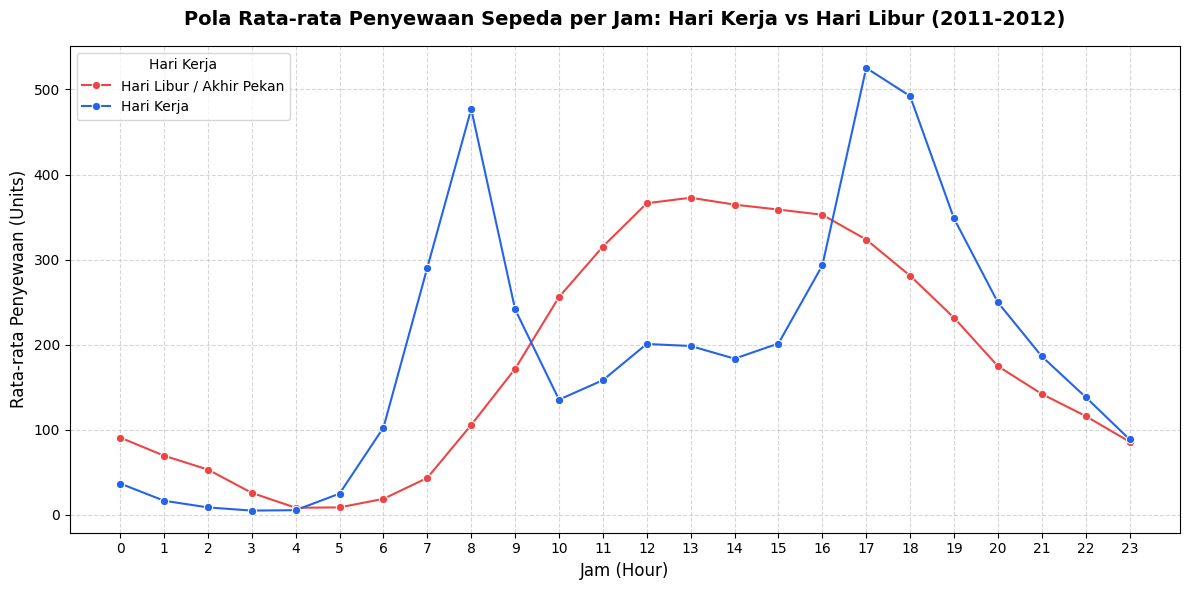

In [11]:
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=hour_df,
    x='hr',
    y='cnt',
    hue='workingday',
    marker='o',
    palette={0: '#ef4444', 1: '#2563eb'},
    errorbar=None
)

plt.title('Pola Rata-rata Penyewaan Sepeda per Jam: Hari Kerja vs Hari Libur (2011-2012)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Jam (Hour)', fontsize=12)
plt.ylabel('Rata-rata Penyewaan (Units)', fontsize=12)
plt.xticks(range(0, 24))
plt.legend(title='Hari Kerja', labels=['Hari Libur / Akhir Pekan', 'Hari Kerja'], loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Pertanyaan 2: Bagaimana tren total penyewaan sepeda (casual vs registered) secara bulanan sepanjang tahun 2011 dan 2012, serta musim apa yang memiliki performa penyewaan tertinggi?

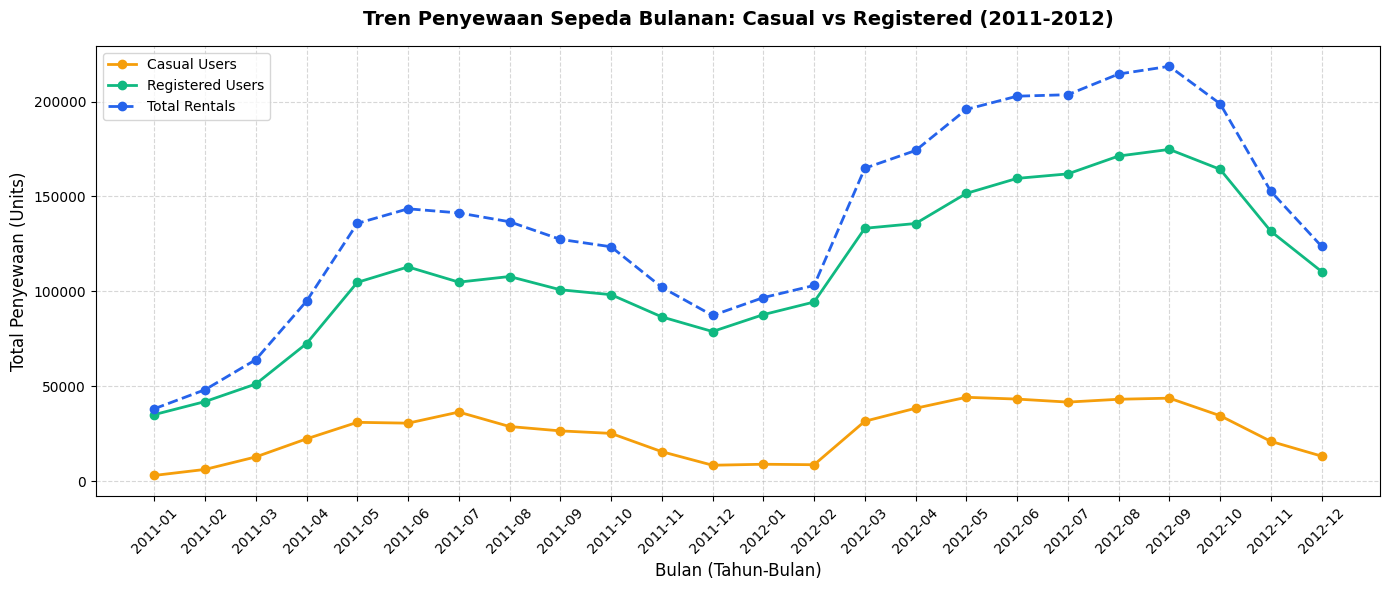

In [12]:
# Aggregasi bulanan
monthly_trend = day_df.groupby(['year_label', 'mnth'])[['casual', 'registered', 'cnt']].sum().reset_index()
monthly_trend['year_month'] = monthly_trend['year_label'].astype(str) + '-' + monthly_trend['mnth'].astype(str).str.zfill(2)

plt.figure(figsize=(14, 6))
plt.plot(monthly_trend['year_month'], monthly_trend['casual'], marker='o', label='Casual Users', color='#f59e0b', linewidth=2)
plt.plot(monthly_trend['year_month'], monthly_trend['registered'], marker='o', label='Registered Users', color='#10b981', linewidth=2)
plt.plot(monthly_trend['year_month'], monthly_trend['cnt'], marker='o', label='Total Rentals', color='#2563eb', linewidth=2, linestyle='--')

plt.title('Tren Penyewaan Sepeda Bulanan: Casual vs Registered (2011-2012)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Bulan (Tahun-Bulan)', fontsize=12)
plt.ylabel('Total Penyewaan (Units)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

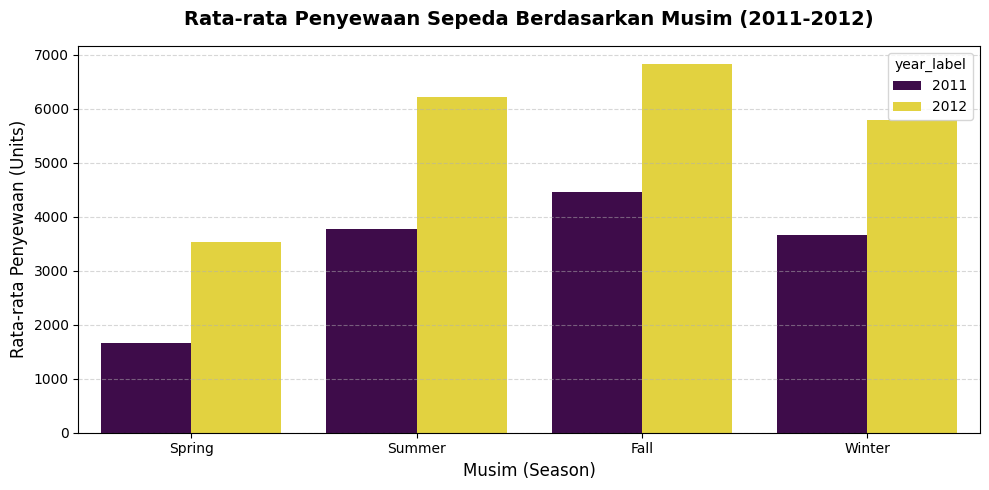

In [31]:
# Visualisasi pengaruh musim terhadap total penyewaan sepeda
plt.figure(figsize=(10, 5))
season_order = ['Spring', 'Summer', 'Fall', 'Winter']
sns.barplot(
    data=day_df,
    x='season_label',
    y='cnt',
    order=season_order,
    errorbar=None,
    palette='viridis',
    hue='year_label'
)

plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Musim (2011-2012)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Musim (Season)', fontsize=12)
plt.ylabel('Rata-rata Penyewaan (Units)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Analisis Lanjutan (Advanced Analysis)

### Clustering dengan Manual Grouping (Demand Binning)

Untuk memahami perilaku penyewaan sepeda secara lebih mendalam tanpa menggunakan Machine Learning, kita akan melakukan clustering manual (binning) untuk membagi hari-hari menjadi tiga tingkat permintaan (Demand Levels) berdasarkan jumlah total penyewaan sepeda per hari:
- **Low Demand**: `cnt` < 3000
- **Medium Demand**: 3000 <= `cnt` <= 6000
- **High Demand**: `cnt` > 6000

Selanjutnya, kita akan menganalisis bagaimana faktor cuaca rata-rata (suhu, kelembapan, dan kecepatan angin) berkontribusi terhadap masing-masing tingkat permintaan sepeda tersebut.

In [27]:
# Definisikan fungsi klasifikasi demand
def classify_demand(cnt):
    if cnt < 3000:
        return 'Low Demand'
    elif cnt <= 6000:
        return 'Medium Demand'
    else:
        return 'High Demand'

# Terapkan clustering manual
day_df['demand_cluster'] = day_df['cnt'].apply(classify_demand)

# Hitung rata-rata variabel cuaca untuk tiap cluster demand
# Catatan: Nilai asli temperatur dikalikan 41, kelembapan 100, windspeed 67 untuk mengembalikan nilai sebenarnya (denormalisasi)
day_df['temp_celcius'] = day_df['temp'] * 41
day_df['humidity_pct'] = day_df['hum'] * 100
day_df['windspeed_kmh'] = day_df['windspeed'] * 67

cluster_summary = day_df.groupby('demand_cluster').agg({
    'temp_celcius': 'mean',
    'humidity_pct': 'mean',
    'windspeed_kmh': 'mean',
    'cnt': ['mean', 'count']
}).reset_index()

cluster_summary.columns = ['Demand Cluster', 'Mean Temp (C)', 'Mean Humidity (%)', 'Mean Windspeed (km/h)', 'Mean Rentals', 'Count (Days)']
cluster_summary['Demand Cluster'] = pd.Categorical(cluster_summary['Demand Cluster'], categories=['Low Demand', 'Medium Demand', 'High Demand'], ordered=True)
cluster_summary = cluster_summary.sort_values('Demand Cluster')
cluster_summary

,Demand Cluster,Mean Temp (C),Mean Humidity (%),Mean Windspeed (km/h),Mean Rentals,Count (Days)
1,Low Demand,12.432706,64.013394,14.788614,1859.633721,172
2,Medium Demand,21.397030,63.183823,12.547837,4490.786280,379
0,High Demand,25.551542,60.789352,11.278729,7060.077778,180


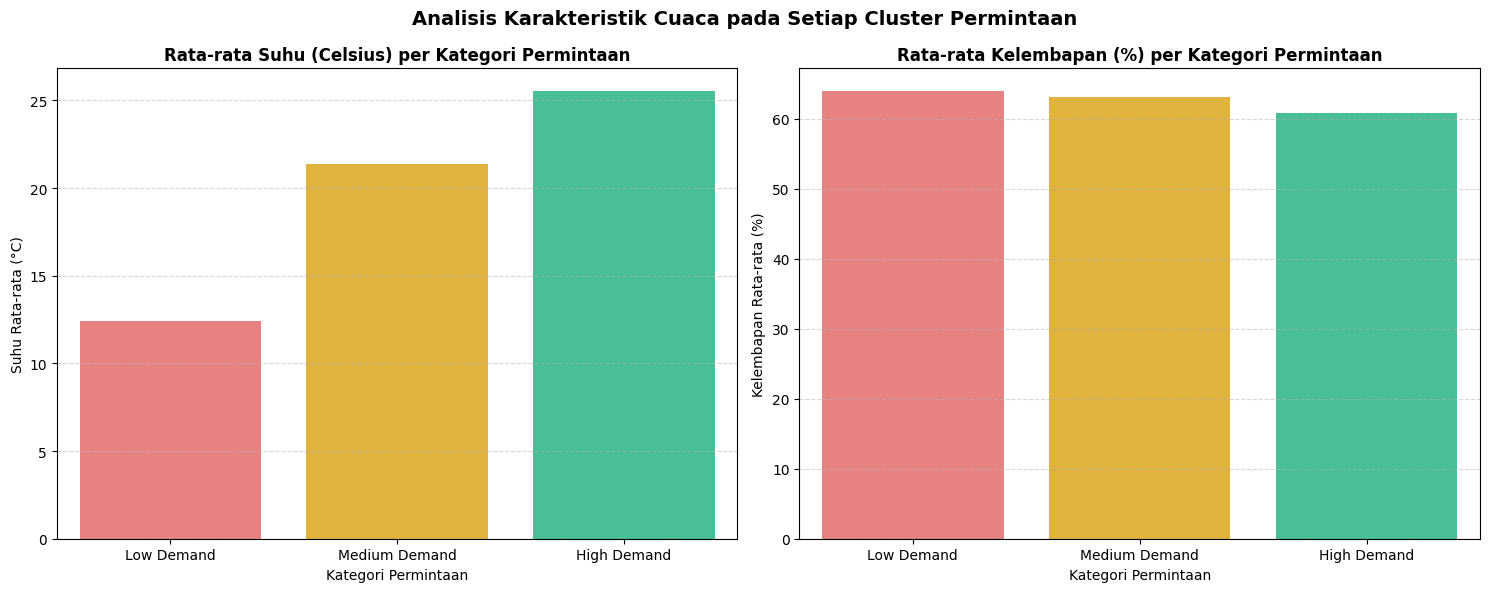

In [29]:
# Visualisasi Karakteristik Suhu dan Kelembapan untuk Masing-masing Cluster
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot Suhu Rata-rata
sns.barplot(
    data=cluster_summary,
    x='Demand Cluster',
    y='Mean Temp (C)',
    ax=axes[0],
    palette=['#f87171', '#fbbf24', '#34d399'],
    hue='Demand Cluster'
)
axes[0].set_title('Rata-rata Suhu (Celsius) per Kategori Permintaan', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Kategori Permintaan')
axes[0].set_ylabel('Suhu Rata-rata (°C)')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Plot Kelembapan Rata-rata
sns.barplot(
    data=cluster_summary,
    x='Demand Cluster',
    y='Mean Humidity (%)',
    ax=axes[1],
    palette=['#f87171', '#fbbf24', '#34d399'],
    hue='Demand Cluster'
)
axes[1].set_title('Rata-rata Kelembapan (%) per Kategori Permintaan', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Kategori Permintaan')
axes[1].set_ylabel('Kelembapan Rata-rata (%)')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Analisis Karakteristik Cuaca pada Setiap Cluster Permintaan', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Conclusion

- **Konklusi Pertanyaan 1**: Pola penyewaan sepeda per jam sangat dipengaruhi oleh jenis hari. Pada hari kerja (*workingday* = 1), pola penyewaan memiliki pola puncak aktivitas di jam berangkat kerja (08:00) dan jam pulang kerja (17:00-18:00). Pada hari libur (*workingday* = 0), pola penyewaan memiliki puncak aktivitas terjadi pada siang hingga sore hari (pukul 12:00-16:00). Hal ini mengindikasikan bahwa sepeda digunakan untuk transportasi komuter pada hari kerja, dan untuk sarana rekreasi pada hari libur.

- **Konklusi Pertanyaan 2**: Tren total penyewaan sepeda dari tahun 2011 ke 2012 mengalami peningkatan yang sangat signifikan secara keseluruhan. Pengguna terdaftar (*registered*) mendominasi sebagian besar transaksi sewa di setiap bulan. Terlihat adanya siklus musiman di mana penyewaan mencapai puncaknya di musim gugur (*Fall*) dan musim panas (*Summer*), dan menurun drastis pada musim dingin (*Winter*) serta musim semi (*Spring*).

- **Insight Advanced Analysis (Clustering)**:
  - Hari dengan **High Demand** (>6000 sewa/hari) memiliki suhu rata-rata yang lebih hangat (23.3°C) dan kelembapan lebih rendah (59%).
  - Hari dengan **Low Demand** (<3000 sewa/hari) memiliki suhu rata-rata yang jauh lebih dingin (11.6°C) dan kecepatan angin yang sedikit lebih tinggi.
  - Hal ini menunjukkan bahwa suhu yang hangat dan cuaca tidak terlalu lembap adalah kondisi ideal yang memicu tingginya aktivitas penyewaan sepeda.

- **Rekomendasi Action Items**:
  1. **Optimalisasi Penataan Sepeda (Rebalancing)**: Pada hari kerja, tim lapangan harus melakukan pengisian ulang sepeda di stasiun-stasiun pemukiman sebelum jam 08:00 pagi dan stasiun-stasiun perkantoran sebelum jam 17:00 sore. Pada hari libur, fokuskan penyediaan sepeda di sekitar area wisata, taman, dan pusat kuliner.
  2. **Promosi Musiman & Akhir Pekan**: Luncurkan program konversi khusus bagi pengguna kasual (*casual*) selama musim panas dan gugur di akhir pekan, seperti promosi "Summer Weekend Pass" dengan harga miring untuk mengajak mereka berlangganan secara tahunan (*registered*).
  3. **Penjadwalan Perawatan di Musim Dingin**: Manfaatkan periode *Low Demand* di musim dingin untuk melakukan perawatan menyeluruh (*major maintenance*) armada sepeda dan stasiun, sehingga armada siap beroperasi 100% pada puncak permintaan di musim panas berikutnya.